In [2]:
import sys
sys.path.append('../../../Share')
import config, baseline, Target, Model

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


from collections import Counter

def balance_data(X, y):
    # Count samples per class
    class_counts = Counter(y)
    min_count = min(class_counts.values())  # target: balance all to minority count

    indices_list = []

    for label in sorted(class_counts.keys()):
        label_indices = np.where(y == label)[0]
        selected_indices = np.random.choice(label_indices, size=min_count, replace=False)
        indices_list.extend(selected_indices)

    # Shuffle all selected indices
    balanced_indices = np.random.permutation(indices_list)

    # Subset the data
    X_balanced = X[balanced_indices]
    y_balanced = y[balanced_indices]

    return X_balanced, y_balanced

In [2]:
baseline_K_val = [i for i in range(len(config.dataset_sub_B))]
SUBJECT = "Brian"


ACC_lst = []
for i, K in enumerate(baseline_K_val[1:-1]):
    trainer = baseline.ModelTrainer(config, subject=f"{SUBJECT}")
    X_train, y_train, _, _ = trainer.return_until_K_data(K, train_ratio=1)
    X_train, y_train = balance_data(X_train, y_train)

    X_test, y_test, _, _ = trainer.return_K_th_data_only(K+1, train_ratio=1)
    X_test, y_test = balance_data(X_test, y_test)

    model = Model.Original_model(X_train.shape[1:], num_class=6)

    #print(pd.Series(y_test).value_counts())

    history, _ = Model.Train_model_without_test(model, X_train, y_train, set_epoch=100, set_batch_size=128, Model_name='', set_verbose=False, save_model_set=False)
    acc = model.evaluate(X_test, y_test, verbose=0)[1]
    ACC_lst.append(acc)
    print(ACC_lst, f"{i}/{len(baseline_K_val)}\n\n")
    pd.DataFrame(history.history).to_csv(f'./Result/{SUBJECT}/train_with_{K}_test_with_next_session.csv', index=False)


Dataset 1/14 - Session Exp_2025-06-27-v1/E9AD0E7DCC2B/
ERROR! Session/line number was not unique in database. History logging moved to new session 3952
Returning K-th session data: Exp_2025-07-09-v1/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.4843597114086151] 0/14


Dataset 1/14 - Session Exp_2025-06-27-v1/E9AD0E7DCC2B/
Dataset 2/14 - Session Exp_2025-06-27-v2/E9AD0E7DCC2B/
Returning K-th session data: Exp_2025-07-09-v2/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.4843597114086151, 0.4377838373184204] 1/14


Dataset 1/14 - Session Exp_2025-06-27-v1/E9AD0E7DCC2B/
Dataset 2/14 - Session Exp_2025-06-27-v2/E9AD0E7DCC2B/
Dataset 3/14 - Session Exp_2025-07-09-v1/E9AD0E7DCC2B/
Returning K-th session data: Exp_2025-07-10-v1/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.4843597114086151, 0.4377838373184204, 0.6800172328948975] 2/14


Dataset 1/14 - Session Exp_2025-06-27-v1/E9AD0E7DCC2B/
Dataset 2/14 - Session Exp_2025-06-27-v2/E9AD0E7DCC2B/
Dataset 3/14 - Session

In [7]:
baseline_K_val = [i for i in range(len(config.dataset_sub_B))]
SUBJECT = "Brian"

ACC_lst_target = []
for i, K in enumerate(baseline_K_val[1:-1]):
    trainer = baseline.ModelTrainer(config, subject=f"{SUBJECT}")
    X_train, y_train, X_test, y_test = trainer.return_K_th_data_only(K, train_ratio=0.7)
    X_train, y_train = balance_data(X_train, y_train)
    X_test, y_test = balance_data(X_test, y_test)

    model = Model.Original_model(X_train.shape[1:], num_class=6)

    history, _ = Model.Train_model_without_test(model, X_train, y_train, set_epoch=100, set_batch_size=128, Model_name='', set_verbose=False, save_model_set=False)
    acc = model.evaluate(X_test, y_test, verbose=0)[1]
    ACC_lst_target.append(acc)
    print(ACC_lst_target, f"{i}/{len(baseline_K_val)}\n\n")
    #pd.DataFrame(history.history).to_csv(f'./Result/{SUBJECT}/train_with_{K}_test_with_next_session.csv', index=False)


Returning K-th session data: Exp_2025-06-27-v2/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.9100528955459595] 0/14


Returning K-th session data: Exp_2025-07-09-v1/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.9100528955459595, 0.9567901492118835] 1/14


Returning K-th session data: Exp_2025-07-09-v2/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.9100528955459595, 0.9567901492118835, 0.8497023582458496] 2/14


Returning K-th session data: Exp_2025-07-10-v1/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.9100528955459595, 0.9567901492118835, 0.8497023582458496, 0.9455128312110901] 3/14


Returning K-th session data: Exp_2025-07-10-v2/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.9100528955459595, 0.9567901492118835, 0.8497023582458496, 0.9455128312110901, 0.8938053250312805] 4/14


Returning K-th session data: Exp_2025-07-16-v1/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.9100528955459595, 0.9567901492118835, 0.8497023582458496, 0.945

In [8]:
ACC_lst_target

[0.9100528955459595,
 0.9567901492118835,
 0.8497023582458496,
 0.9455128312110901,
 0.8938053250312805,
 0.9172494411468506,
 0.9448924660682678,
 0.9454277157783508,
 0.9497126340866089,
 0.9272727370262146,
 0.9219576716423035,
 0.9608585834503174]

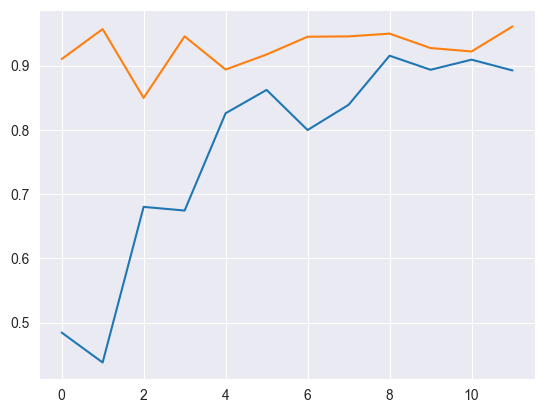

In [9]:
plt.plot(ACC_lst)
plt.plot(ACC_lst_target)

Dataset 1/14 - Session Exp_2025-06-27-v1/E9AD0E7DCC2B/
Dataset 2/14 - Session Exp_2025-06-27-v2/E9AD0E7DCC2B/
Dataset 3/14 - Session Exp_2025-07-09-v1/E9AD0E7DCC2B/
Dataset 4/14 - Session Exp_2025-07-09-v2/E9AD0E7DCC2B/
Dataset 5/14 - Session Exp_2025-07-10-v1/E9AD0E7DCC2B/
Dataset 6/14 - Session Exp_2025-07-10-v2/E9AD0E7DCC2B/
Dataset 7/14 - Session Exp_2025-07-16-v1/E9AD0E7DCC2B/
Dataset 8/14 - Session Exp_2025-07-16-v2/E9AD0E7DCC2B/
Dataset 9/14 - Session Exp_2025-07-17-v1/E9AD0E7DCC2B/
Dataset 10/14 - Session Exp_2025-07-17-v2/E9AD0E7DCC2B/
Dataset 11/14 - Session Exp_2025-07-24-v1/E9AD0E7DCC2B/
Dataset 12/14 - Session Exp_2025-07-24-v2/E9AD0E7DCC2B/
Returning K-th session data: Exp_2025-08-01-v2/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
Maximum training accuracy : 88.25%
Maximum validation accuracy : 90.01%
0.9000809192657471
0.9000809192657471


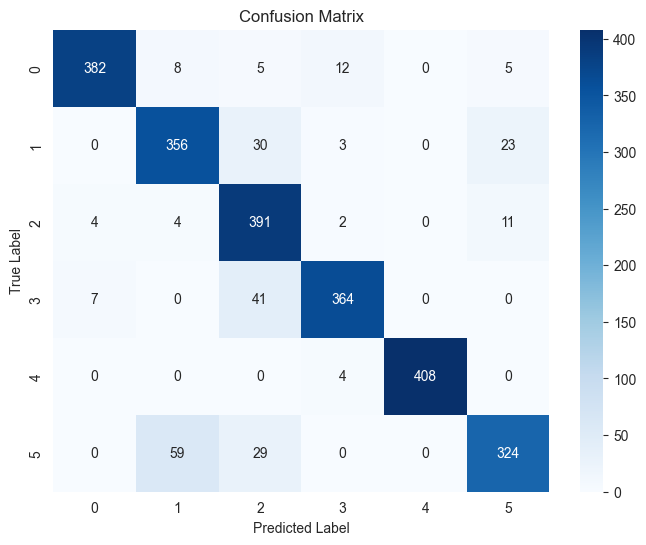

In [20]:
baseline_K_val = [i for i in range(len(config.dataset_sub_B))]
SUBJECT = "Brian"

from sklearn.metrics import confusion_matrix
import seaborn as sns
from tensorflow import keras


def heatmap_confusion_matrix(X_test, y_test, model):
    # Predict class labels on the test set
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)  # convert softmax probs to predicted class
    y_true = y_test
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(np.max(y_test)+1), yticklabels=range(np.max(y_test)+1))
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

    return cm


#가장 좋은 거 return

for i, K in enumerate([baseline_K_val[-2]]):
    trainer = baseline.ModelTrainer(config, subject=f"{SUBJECT}")
    X_train, y_train, _, _ = trainer.return_until_K_data(K, train_ratio=1)
    X_train, y_train = balance_data(X_train, y_train)

    X_test, y_test, _, _ = trainer.return_K_th_data_only(K+1, train_ratio=1)
    X_test, y_test = balance_data(X_test, y_test)

    model = Model.Original_model(X_train.shape[1:], num_class=6)

    #history, _ = Model.Train_model_without_test(model, X_train, y_train, set_epoch=100, set_batch_size=128, Model_name='Brian_best_model', set_verbose=False, save_model_set=True)

    history, _ =  Model.Train_model(model, X_train, y_train, X_test, y_test, set_epoch=100, set_batch_size=128, Model_name='Brian_best_model', set_verbose=False, save_model_set=True)

    acc = model.evaluate(X_test, y_test, verbose=0)[1]
    print(acc)

    model_best = keras.models.load_model('Brian_best_model.keras')

    acc = model_best.evaluate(X_test, y_test, verbose=0)[1]
    print(acc)

    cm = heatmap_confusion_matrix(X_test, y_test, model)


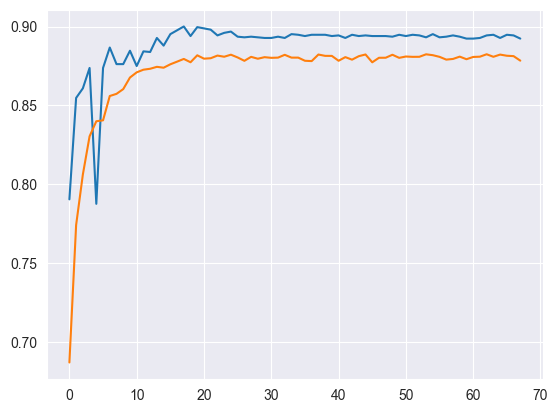

In [21]:
plt.plot(history.history['val_accuracy'])
plt.plot(history.history['accuracy'])
plt.show()

In [3]:
CM = [[371, 9, 8, 11, 1, 12],
 [0, 355, 34, 2, 0, 21],
 [0, 6, 403, 0, 0, 3],
 [2, 0, 25, 385, 0, 0],
 [0, 0, 0, 6, 406, 0],
 [0, 32, 22, 0, 0, 358]]

import numpy as np
accuracy = np.trace(CM) / np.sum(CM)
print(f"Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Overall Accuracy: 0.9215 (92.15%)
